In [53]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

from highlight_text import ax_text, fig_text
from drawarrow import ax_arrow, fig_arrow
from pyfonts import load_google_font

In [16]:
data_path = os.path.join(
    "..", "data",
    "india_quick.xlsx"
)

data = pd.read_excel(data_path)

data.head()

,Quarter,Zomato - Food Delivery Share of Total Revenue,Zomato - Quick Commerce Share of Total Revenue,Swiggy - Food Delivery Share of Total Revenue,Swiggy - Quick Commerce Share of Total Revenue,Quarter Label,Quarter Index
0,Q4FY22,0.834,0.000,NaN,NaN,Q4,1
1,Q1FY23,0.812,0.000,NaN,NaN,Q1,2
2,Q2FY23,0.750,0.067,NaN,NaN,Q2,3
3,Q3FY23,0.662,0.127,NaN,NaN,Q3,4
4,Q4FY23,0.634,0.150,NaN,NaN,Q4,5


In [15]:
data["Quarter"].iloc[-1]

'Q4FY26'

In [9]:
# Color Customizations

# Common
grey = "#6c757d"
bg = "white"

# Zomato
z_colors = {
    "z_food":"#780000",
    "z_quick":"#ffb703"
}

# Swiggy
s_colors = {
    "s_food":"#ff6700",
    "s_quick":"#0466c8"
}


# Font Customizations

fonts = {
    "main":load_google_font("Noto Serif", weight=600),
    "italic":load_google_font("Noto Serif", italic=True),
    "bold":load_google_font("Noto Serif", weight=800),
    "bold_italic":load_google_font("Noto Serif", weight=600, italic=True)
}

In [3]:
# Title
title = """
        <Quick Commerce> Overtakes Food Delivery
        """

# Subtitle
subtitle = """
        A structural shift in India’s food-tech revenue mix
        """

# Data story
data_story = """
        Quick commerce has moved from a side business\n
        to a major revenue engine.\n
        For Zomato, the revenue mix now shows a clear\n
        crossover: quick commerce has overtaken food delivery.\n\n
        A similar trend is visible with <Swiggy> as well.
        """


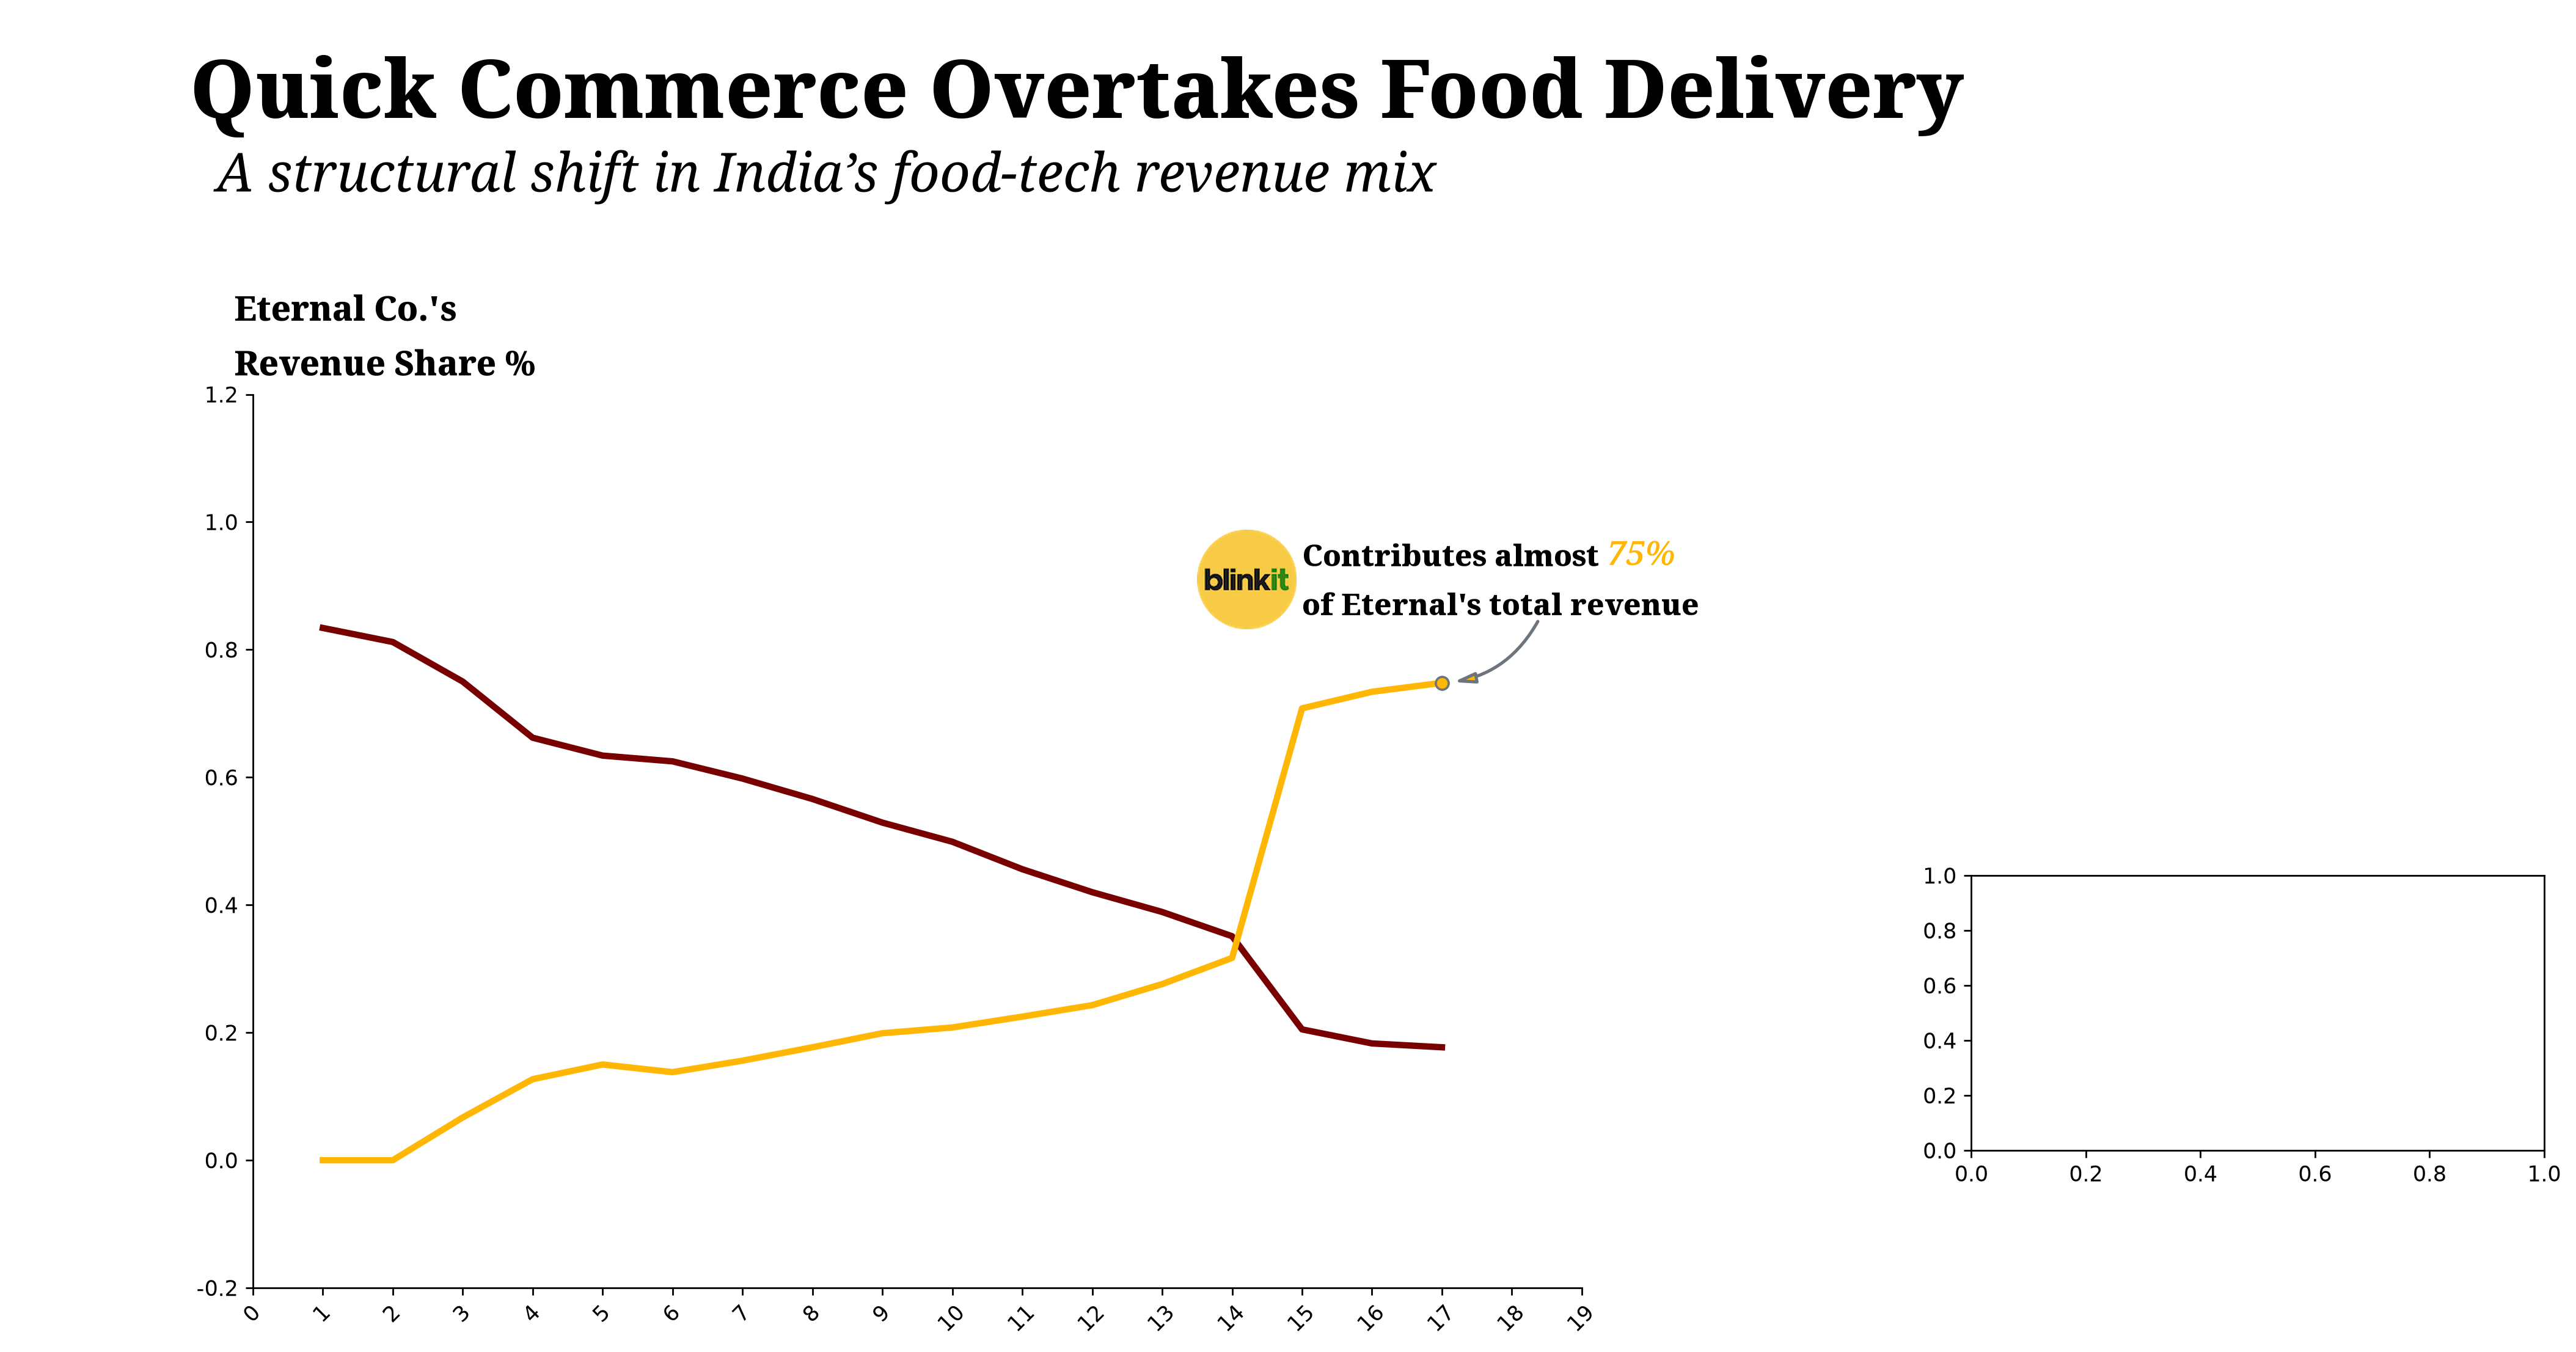

In [84]:
# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(15, 9), facecolor=bg, dpi=250)

# -----------------------------
# Axes layout
# [left, bottom, width, height]
# -----------------------------
ax_zomato = fig.add_axes([0.1, 0.02, 0.58, 0.65])
ax_swiggy = fig.add_axes([0.85, 0.12, 0.25, 0.2])

ax_zomato.set_facecolor(bg)
ax_zomato.spines[["top", "right"]].set_visible(0)

# -----------------------------
# Title + subtitle
# -----------------------------
fig_text(
    x=0.0, y=0.94,
    s=title,
    fontsize=38,
    font=fonts["bold"],
    highlight_textprops=[dict(font=fonts["bold"])]
)

fig_text(
    x=0.035, y=0.865,
    s=subtitle,
    fontsize=25,
    font=fonts["italic"]
)


# -----------------------------
# Zomato chart
# -----------------------------
ax_zomato.plot(
    data["Quarter Index"],
    data["Zomato - Food Delivery Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_food"]
)

ax_zomato.plot(
    data["Quarter Index"],
    data["Zomato - Quick Commerce Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_quick"]
)

# ax_zomato.set_title("Zomato | Share of Revenue (%)", loc="left", fontsize=13, font=fonts["main_head"])
fig_text(
    x=0.092, y=0.75,
    s="Eternal Co.'s\nRevenue Share %",
    fontsize=16,
    font=fonts["bold"]
)
# ax_zomato.set_ylabel("Share of revenue (%)", font=fonts["main_head"])
ax_zomato.tick_params(axis="x", rotation=45)

# last points
last_quarter = data["Quarter Index"].iloc[-1]
last_food_share = data["Zomato - Food Delivery Share of Total Revenue"].iloc[-1]
last_quick_share = data["Zomato - Quick Commerce Share of Total Revenue"].iloc[-1]


# line-end labels

# ax_zomato.grid()
ax_zomato.set_xlim(0,19)
ax_zomato.set_xticks(ticks=range(0,20,1), labels=range(0,20,1))

ax_zomato.set_ylim(0, 1.2)
ax_zomato.set_yticks(
    ticks=np.arange(-0.2, 1.21, 0.2),
    labels=[f"{x:.1f}" for x in np.arange(-0.2, 1.21, 0.2)]
)

# quick commerce callout
blinkit_logo = mpimg.imread(os.path.join("..", "data", "blinkit.png"))

imagebox = OffsetImage(
    blinkit_logo,
    zoom=0.5,              # adjust as required
    interpolation="lanczos"
)

ab = AnnotationBbox(
    imagebox,
    (13.5, 0.91),   # data coordinates
    frameon=False,
    box_alignment=(0, 0.5),            # left-center of logo
    zorder=10
)

ax_zomato.add_artist(ab)

ax_text(
    x=15,
    y=0.915,
    s="Contributes almost <75><%>\nof Eternal's total revenue",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=14,
    ha="left",
    va="center",
    highlight_textprops=[
        dict(font=fonts["bold_italic"], color=z_colors["z_quick"], fontsize=16),
        dict(font=fonts["bold_italic"], color=z_colors["z_quick"], fontsize=16)
        ]
)
ax_arrow(
    tail_position=(18.4, 0.85),
    head_position=(last_quarter+0.1, last_quick_share),
    radius=-0.25, head_width=2, ax=ax_zomato,
    facecolor=z_colors["z_quick"], edgecolor=grey, width=1.5
)
ax_zomato.scatter([17, 17], [last_quick_share,last_quick_share],
                  zorder=5, marker="o",
                  color=z_colors["z_quick"], edgecolors=grey)







# -----------------------------
# Story text
# -----------------------------
# fig_text(
#     x=0.78,
#     y=0.6,
#     s=data_story,
#     font=fonts["main"],
#     fontsize=12,
#     fig=fig,
#     highlight_textprops=[dict(font=fonts["italic"])]
# )



# -----------------------------
# Swiggy chart
# -----------------------------
# ax_swiggy.plot(
#     data["Quarter Index"],
#     data["Swiggy - Food Delivery Share of Total Revenue"],
#     linewidth=2,
#     color=s_colors["s_food"]
# )

# ax_swiggy.plot(
#     data["Quarter Index"],
#     data["Swiggy - Quick Commerce Share of Total Revenue"],
#     linewidth=2,
#     color=s_colors["s_quick"]
# )

# ax_swiggy.set_title("Swiggy | Share of Revenue (%)", loc="left", fontsize=10, font=fonts["main"])
# ax_swiggy.tick_params(axis="x", rotation=45, labelsize=7)
# ax_swiggy.tick_params(axis="y", labelsize=7)

save_path = os.path.join(
    "..", "viz",
    "test.jpeg"
)

plt.savefig(save_path, dpi=350, bbox_inches="tight", pad_inches=0.5)


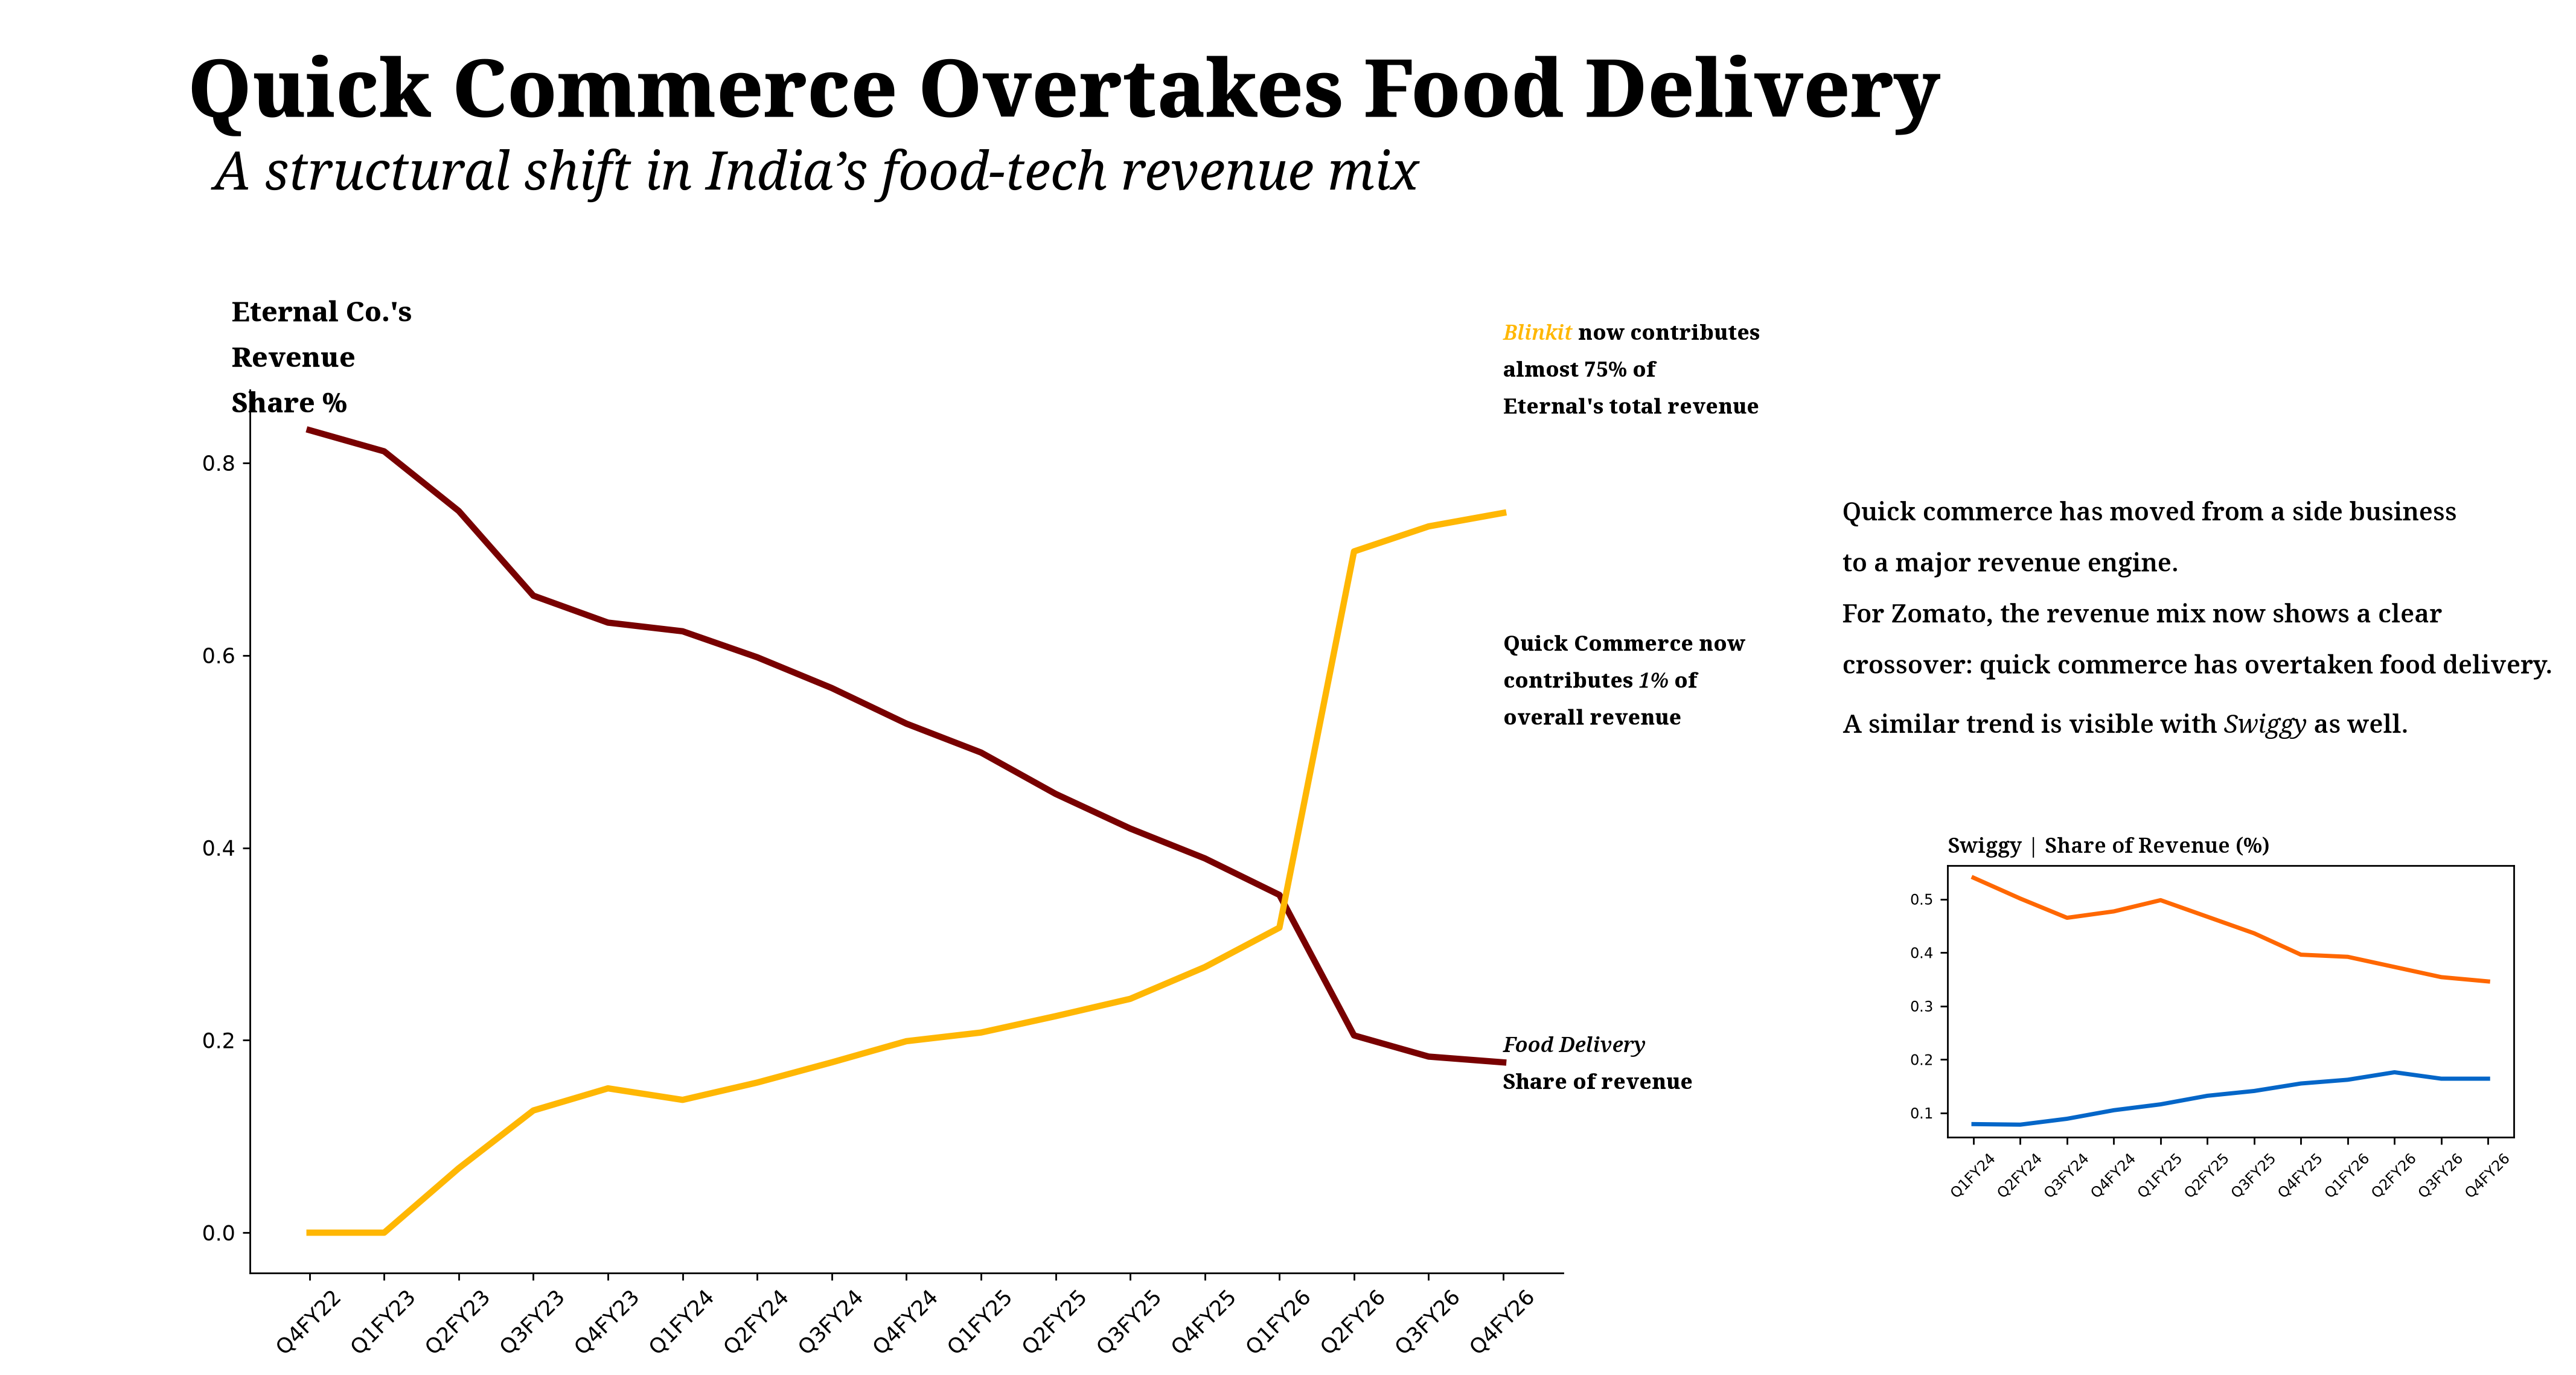

In [ ]:
# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(15, 9), facecolor=bg, dpi=250)

# -----------------------------
# Axes layout
# [left, bottom, width, height]
# -----------------------------
ax_zomato = fig.add_axes([0.1, 0.02, 0.58, 0.65])
ax_swiggy = fig.add_axes([0.85, 0.12, 0.25, 0.2])

ax_zomato.set_facecolor(bg)
ax_zomato.spines[["top", "right"]].set_visible(0)

# -----------------------------
# Title + subtitle
# -----------------------------
fig_text(
    x=0.0, y=0.94,
    s=title,
    fontsize=38,
    font=fonts["bold"],
    highlight_textprops=[dict(font=fonts["bold"])]
)

fig_text(
    x=0.035, y=0.865,
    s=subtitle,
    fontsize=25,
    font=fonts["italic"]
)


# -----------------------------
# Zomato chart
# -----------------------------
ax_zomato.plot(
    data["Quarter"],
    data["Zomato - Food Delivery Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_food"]
)

ax_zomato.plot(
    data["Quarter"],
    data["Zomato - Quick Commerce Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_quick"]
)

# ax_zomato.set_title("Zomato | Share of Revenue (%)", loc="left", fontsize=13, font=fonts["main_head"])
fig_text(
    x=0.092, y=0.742,
    s="Eternal Co.'s\nRevenue\nShare %",
    fontsize=13,
    font=fonts["bold"]
)
# ax_zomato.set_ylabel("Share of revenue (%)", font=fonts["main_head"])
ax_zomato.tick_params(axis="x", rotation=45)

# last points
last_quarter = data["Quarter"].iloc[-1]
last_food_share = data["Zomato - Food Delivery Share of Total Revenue"].iloc[-1]
last_quick_share = data["Zomato - Quick Commerce Share of Total Revenue"].iloc[-1]


# line-end labels
ax_text(
    x=last_quarter,
    y=last_food_share,
    s="<Food Delivery>\nShare of revenue",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=10,
    ha="left",
    va="center",
    highlight_textprops=[dict(font=fonts["bold_italic"])]
)

ax_text(
    x=last_quarter,
    y=last_quick_share+0.15,
    s="<Blinkit> now contributes\nalmost 75% of\nEternal's total revenue",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=10,
    ha="left",
    va="center",
    highlight_textprops=[dict(font=fonts["bold_italic"], color=z_colors["z_quick"])]
)
ax_arrow(
    tail_position=(last_quarter+, last_quick_share+0.13), head_position=(last_quarter, last_quick_share),
    radius=-0.1
)

# quick commerce callout
ax_text(
    x=last_quarter,
    y=last_quick_share - .12,
    s=f"Quick Commerce now\ncontributes <{last_quick_share:.0f}%> of\noverall revenue",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=10,
    ha="left",
    va="top",
    highlight_textprops=[dict(font=fonts["bold_italic"])]
)



# -----------------------------
# Story text
# -----------------------------
fig_text(
    x=0.78,
    y=0.6,
    s=data_story,
    font=fonts["main"],
    fontsize=12,
    fig=fig,
    highlight_textprops=[dict(font=fonts["italic"])]
)



# -----------------------------
# Swiggy chart
# -----------------------------
ax_swiggy.plot(
    data["Quarter"],
    data["Swiggy - Food Delivery Share of Total Revenue"],
    linewidth=2,
    color=s_colors["s_food"]
)

ax_swiggy.plot(
    data["Quarter"],
    data["Swiggy - Quick Commerce Share of Total Revenue"],
    linewidth=2,
    color=s_colors["s_quick"]
)

ax_swiggy.set_title("Swiggy | Share of Revenue (%)", loc="left", fontsize=10, font=fonts["main"])
ax_swiggy.tick_params(axis="x", rotation=45, labelsize=7)
ax_swiggy.tick_params(axis="y", labelsize=7)

save_path = os.path.join(
    "..", "viz",
    "test.jpeg"
)

plt.savefig(save_path, dpi=350, bbox_inches="tight", pad_inches=0.5)
